In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)

print("All libraries loaded!")

All libraries loaded!


In [10]:
data = sns.load_dataset('titanic')
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [11]:
df = data[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
len(df.columns)

8

In [12]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

C:\Users\rahit\AppData\Local\Temp\ipykernel_25312\3423297211.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age'] = df['age'].fillna(df['age'].median())
C:\Users\rahit\AppData\Local\Temp\ipykernel_25312\3423297211.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [14]:
df['sex'] = LabelEncoder().fit_transform(df['sex'])
df = pd.get_dummies(df, columns = ['embarked'], drop_first = True)
df.head()

C:\Users\rahit\AppData\Local\Temp\ipykernel_25312\4072250039.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex'] = LabelEncoder().fit_transform(df['sex'])


,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


In [15]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [16]:
X = df.drop('survived', axis = 1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)
X_train.shape, X_test.shape

((712, 8), (179, 8))

In [17]:
y_train.value_counts(normalize=True)

survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

In [18]:
y_test.value_counts(normalize=True)

survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64

In [19]:
dt = DecisionTreeClassifier(max_depth=4, random_state=7)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]
print("Single Decision Tree ( Max Depth = 4)")
print("="*45)
print(f"   Training Accuracy : {dt.score(X_train, y_train):.4f}")
print(f"   Testing Accuracy  : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"   Precision.        : {precision_score(y_test, y_pred_dt):.4f}")
print(f"   Recall.           : {recall_score(y_test, y_pred_dt):.4f}")
print(f"   F1 Score.         : {f1_score(y_test, y_pred_dt):.4f}")
print(f"   Auc Roc.          : {roc_auc_score(y_test, y_prob_dt):.4f}")

Single Decision Tree ( Max Depth = 4)
   Training Accuracy : 0.8469
   Testing Accuracy  : 0.8045
   Precision.        : 0.8400
   Recall.           : 0.6087
   F1 Score.         : 0.7059
   Auc Roc.          : 0.8312


# The instability problem

In [21]:
for i in range(5):
    X_sub, X_sub2, y_sub, y_sub2 = train_test_split(X_train, y_train, test_size=0.1)
    dt_sub = DecisionTreeClassifier(max_depth=4, random_state=7)
    dt_sub.fit(X_sub, y_sub)
    acc = accuracy_score(y_test, dt_sub.predict(X_test))
    print(f"Subsample {i+1} Accuracy : {acc:.4f}")

Subsample 1 Accuracy : 0.7933
Subsample 2 Accuracy : 0.8045
Subsample 3 Accuracy : 0.8045
Subsample 4 Accuracy : 0.7933
Subsample 5 Accuracy : 0.7933


# Random Forest

In [29]:
rf = RandomForestClassifier(n_estimators=100, 
                            max_depth=None, 
                            max_features='sqrt', 
                            oob_score=True, 
                            random_state=7, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print(f"   Training Accuracy : {rf.score(X_train, y_train):.4f}")
print(f"   Testing Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"   Precision.        : {precision_score(y_test, y_pred_rf):.4f}")
print(f"   Recall.           : {recall_score(y_test, y_pred_rf):.4f}")
print(f"   F1 Score.         : {f1_score(y_test, y_pred_rf):.4f}")
print(f"   Auc Roc.          : {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"   OOB Score         : {rf.oob_score_:.4f}")

   Training Accuracy : 0.9860
   Testing Accuracy  : 0.7821
   Precision.        : 0.7206
   Recall.           : 0.7101
   F1 Score.         : 0.7153
   Auc Roc.          : 0.8419
   OOB Score         : 0.8132


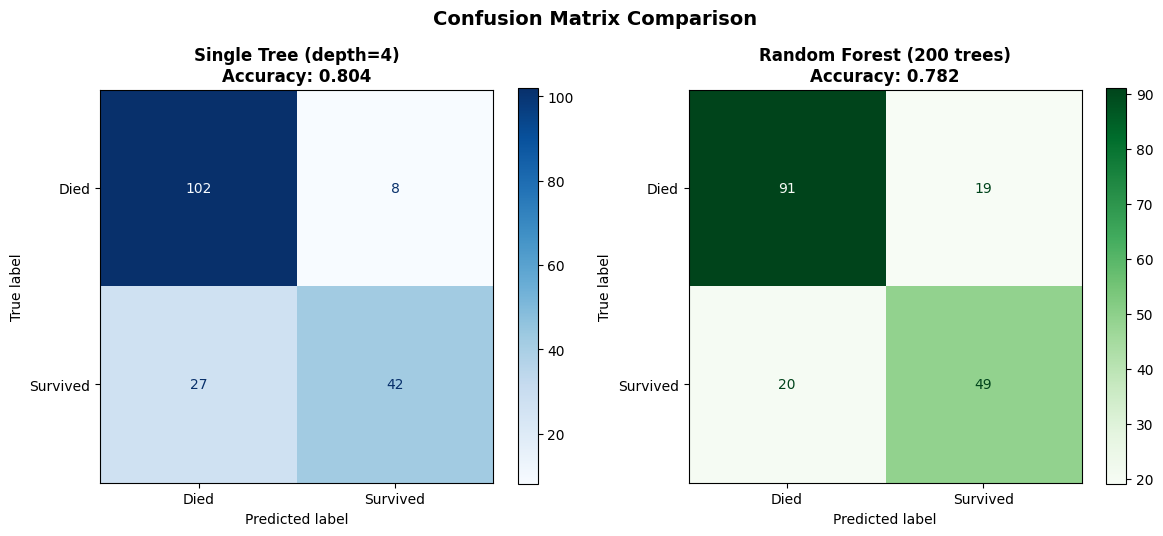

In [30]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=['Died', 'Survived'],
                                         cmap='Blues', ax=axes[0])
axes[0].set_title(f'Single Tree (depth=4)\nAccuracy: {accuracy_score(y_test, y_pred_dt):.3f}',
                  fontsize=12, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['Died', 'Survived'],
                                         cmap='Greens', ax=axes[1])
axes[1].set_title(f'Random Forest (200 trees)\nAccuracy: {accuracy_score(y_test, y_pred_rf):.3f}',
                  fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Hyper Parameters

In [31]:
n_trees = [5, 10, 50, 75, 100,125, 150, 175, 200, 250, 300, 400, 500]
train_accs , test_accs, oob_scores = [], [], []
for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n,
                                oob_score=True,
                                random_state=7,
                                )
    rf.fit(X_train, y_train)
    train_accs.append(rf.score(X_train, y_train))
    test_accs.append(accuracy_score(y_test, rf.predict(X_test)))
    oob_scores.append(rf.oob_score_)
print(f"{'n_trees':>8} {'Train Acc':>10} {'Test Acc':>10} {'OOB Score':>10}")
print("-" * 42)
for n, tr, te, oob in zip(n_trees, train_accs, test_accs, oob_scores):
    print(f"{n:>8} {tr:>10.4f} {te:>10.4f} {oob:>10.4f}")

C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


 n_trees  Train Acc   Test Acc  OOB Score
------------------------------------------
       5     0.9565     0.7821     0.7556
      10     0.9733     0.7709     0.7711
      50     0.9860     0.7709     0.8132
      75     0.9860     0.7821     0.8146
     100     0.9860     0.7821     0.8132
     125     0.9860     0.7877     0.8146
     150     0.9860     0.7821     0.8160
     175     0.9860     0.7821     0.8174
     200     0.9860     0.7877     0.8146
     250     0.9860     0.7821     0.8188
     300     0.9860     0.7877     0.8230
     400     0.9860     0.7821     0.8202
     500     0.9860     0.7821     0.8174


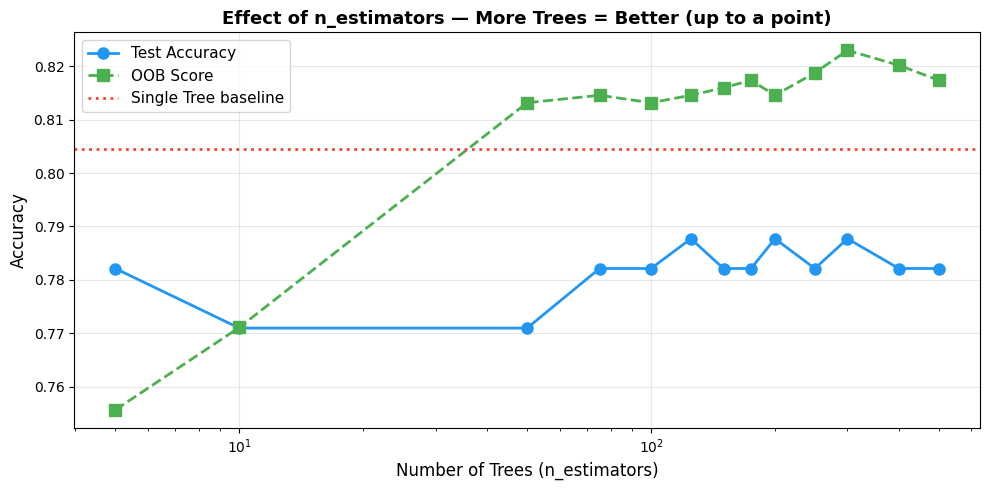


>>> After ~100 trees, adding more barely helps.
>>> Rule of thumb: start with 100-200. Going beyond 500 is rarely worth it.


In [32]:
# Plot n_estimators effect
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_trees, test_accs, 'o-', color='#2196F3', linewidth=2, markersize=8, label='Test Accuracy')
ax.plot(n_trees, oob_scores, 's--', color='#4CAF50', linewidth=2, markersize=8, label='OOB Score')
ax.axhline(y=accuracy_score(y_test, y_pred_dt), color='#F44336', linestyle=':', linewidth=2, label='Single Tree baseline')
ax.set_xlabel('Number of Trees (n_estimators)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Effect of n_estimators — More Trees = Better (up to a point)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n>>> After ~100 trees, adding more barely helps.")
print(">>> Rule of thumb: start with 100-200. Going beyond 500 is rarely worth it.")